Notebook / repo setup (first cell)

In [22]:
# reproducibility and common imports
import random, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

# display settings
pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')


Load data & quick check

In [23]:
df = pd.read_csv(r"D:\FINAL WATER POTABILITY\water_potability.csv")
df.head()
df.info()
df.describe().T
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Exploratory Data Analysis (EDA)

In [24]:
# class balance
df['Potability'].value_counts(normalize=True)

Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64

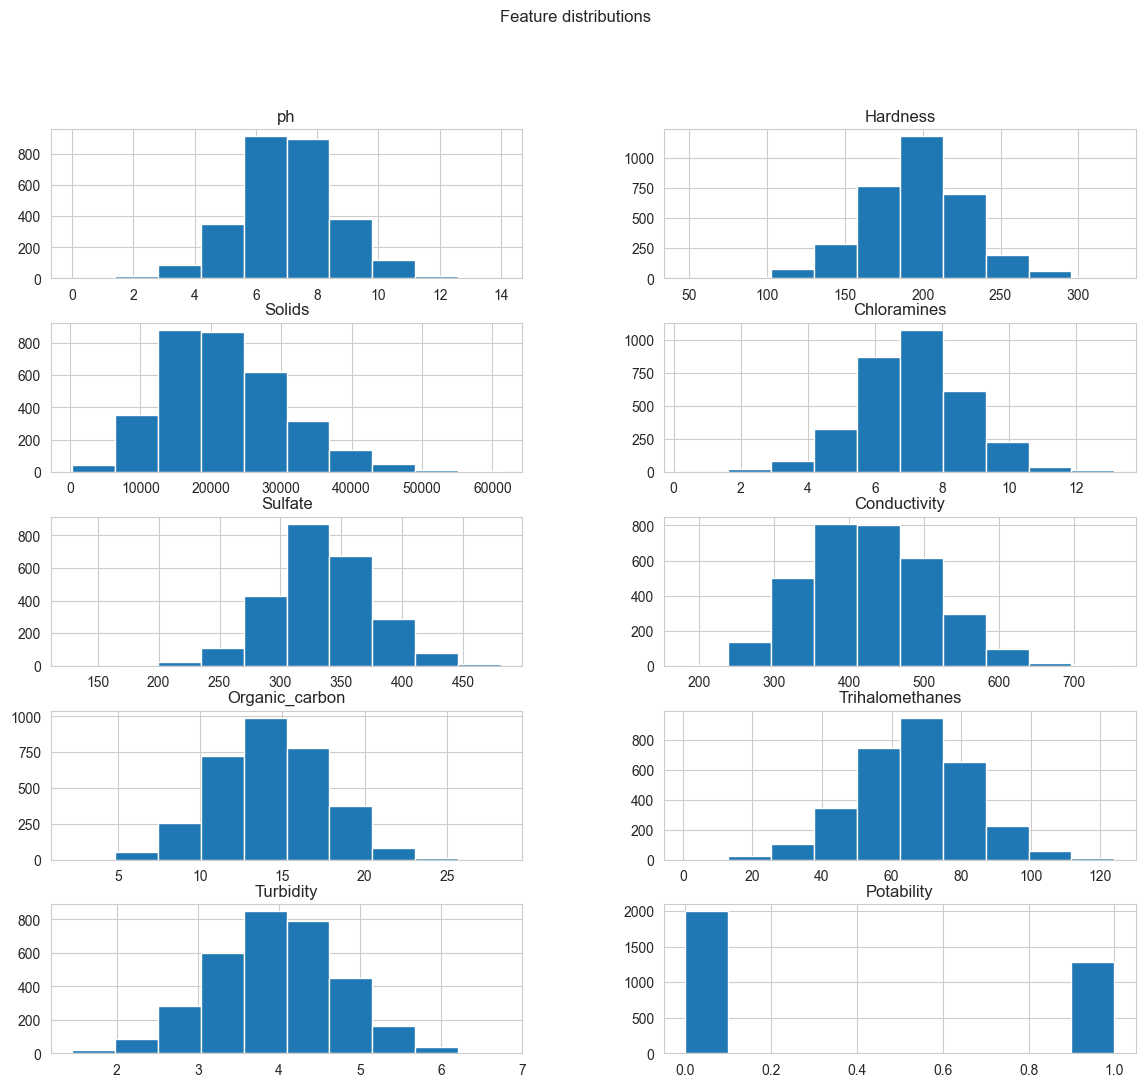

In [25]:
# distributions
df.hist(bins=10, figsize=(14,12), layout=(5,2))
plt.suptitle("Feature distributions")
plt.show()

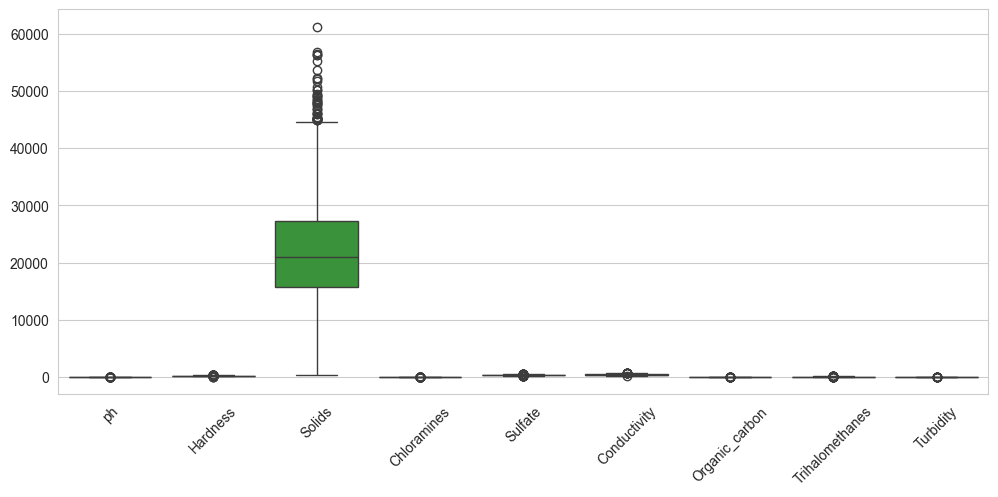

In [26]:
# boxplots (outliers)
plt.figure(figsize=(12,5))
sns.boxplot(data=df.drop(columns='Potability'))
plt.xticks(rotation=45)
plt.show()

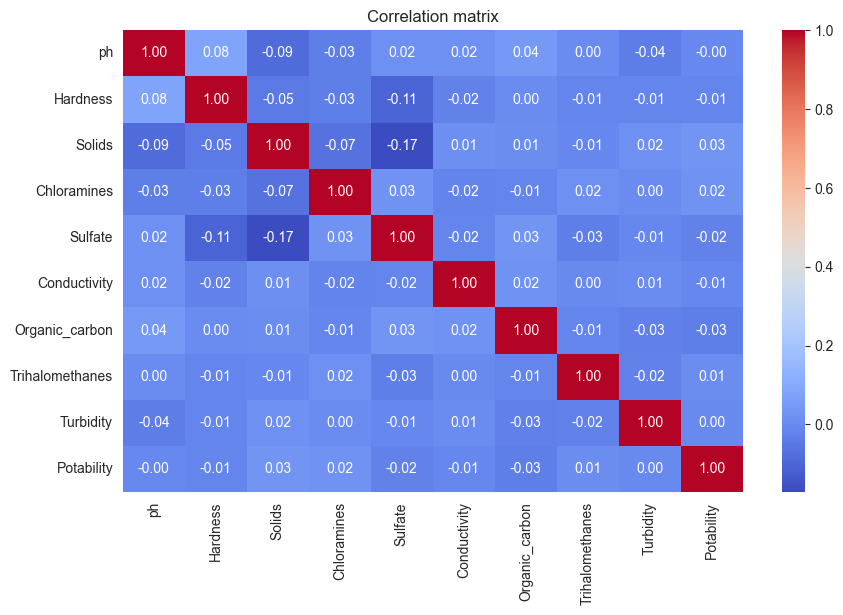

In [27]:
# correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

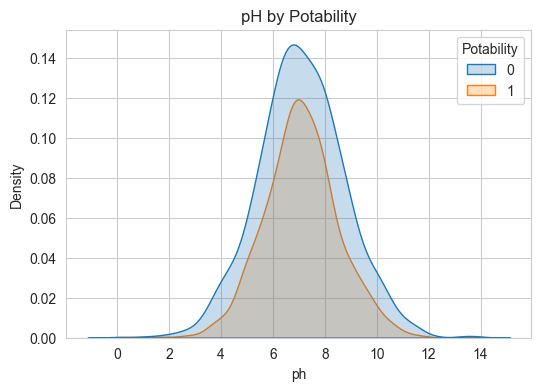

In [28]:
# Compare distributions by target: e.g., pH
plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x='ph', hue='Potability', fill=True)
plt.title("pH by Potability")
plt.show()

Missing values & imputation

In [29]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
X = df.drop('Potability', axis=1)
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
df_imputed = pd.concat([X_imputed, df['Potability'].reset_index(drop=True)], axis=1)


Outliers & transforms

In [30]:
for col in ['Solids','Trihalomethanes','Conductivity']:
    df_imputed[col] = np.log1p(df_imputed[col])


Feature engineering & selection
Keep original features + transforms.

Optionally create interactions (e.g., ph * Hardness) if meaningful.

Use feature selection methods: SelectKBest, Recursive Feature Elimination (RFE) or tree-based importance.

 RFECV with RandomForest:

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

X = df_imputed.drop('Potability', axis=1)
y = df_imputed['Potability']

rf = RandomForestClassifier(random_state=RANDOM_SEED)
rfecv = RFECV(rf, step=1, cv=StratifiedKFold(5), scoring='f1')
rfecv.fit(X, y)
print("Optimal features:", X.columns[rfecv.support_].tolist())


Optimal features: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate']


Preprocessing pipeline (scaling, balancing)

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE   # pip install imbalanced-learn

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # ('smote', SMOTE(random_state=RANDOM_SEED)),  # use only on training
    ('clf', RandomForestClassifier(random_state=RANDOM_SEED))
])


Baseline models
Evaluate several models with cross-validation: LogisticRegression, RandomForest, XGBoost, LightGBM, SVM.

In [33]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

models = {
    'LogReg': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'RF': RandomForestClassifier(random_state=RANDOM_SEED),
    'XGB': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_SEED)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
for name, m in models.items():
    scores = cross_val_score(m, X, y, cv=cv, scoring='f1')
    print(name, "F1 mean:", np.mean(scores), "std:", np.std(scores))


LogReg F1 mean: 0.0 std: 0.0
RF F1 mean: 0.4569133245640595 std: 0.02021641738137913


c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:51:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:51:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:51:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:51:03] WARNING: C:\actio

XGB F1 mean: 0.47126687793398825 std: 0.01674616855938165


c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:51:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Hyperparameter tuning (efficient)
Use RandomizedSearchCV first, then refine with GridSearchCV. Use HalvingGridSearchCV for speed.

 for XGBoost:

In [34]:
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_SEED)
params = {
    'n_estimators': [50,100,200,400],
    'max_depth': [3,4,5,6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6,0.8,1.0],
    'colsample_bytree': [0.6,0.8,1.0]
}

rs = RandomizedSearchCV(xgb, params, n_iter=40, cv=cv, scoring='f1', random_state=RANDOM_SEED, n_jobs=-1)
rs.fit(X, y)
print("Best params:", rs.best_params_)


c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:51:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:51:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


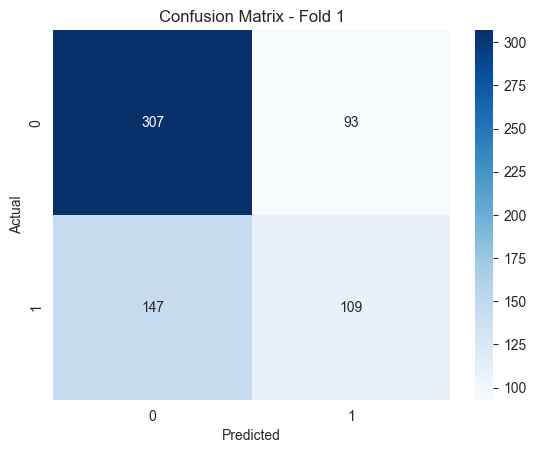

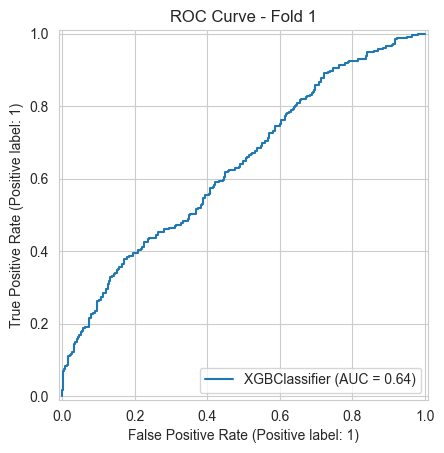

c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:51:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


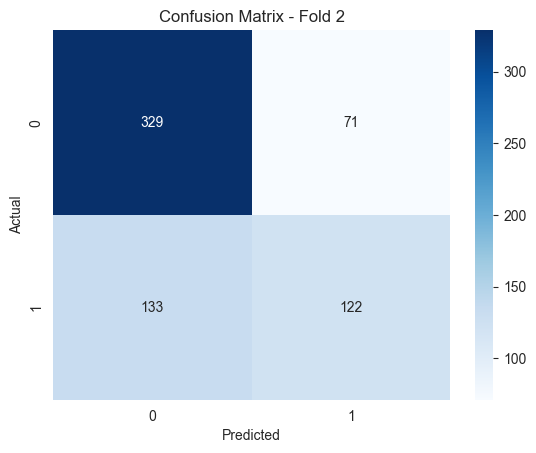

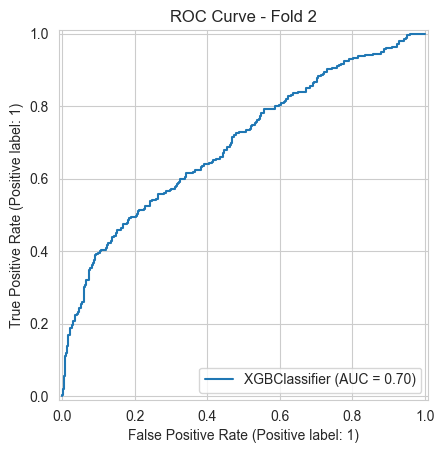

c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:51:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


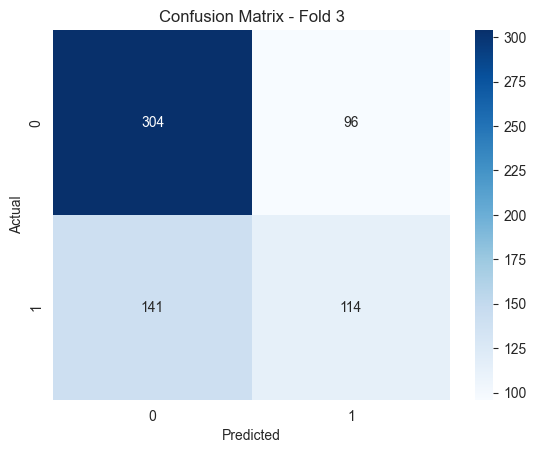

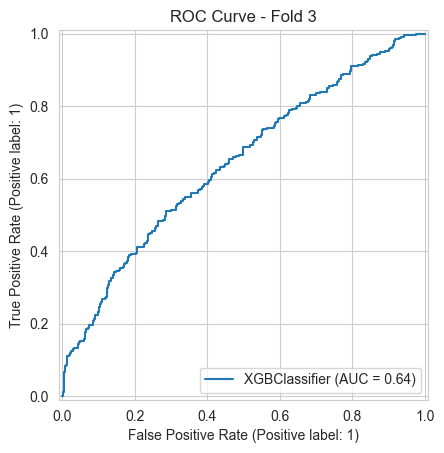

c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:51:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


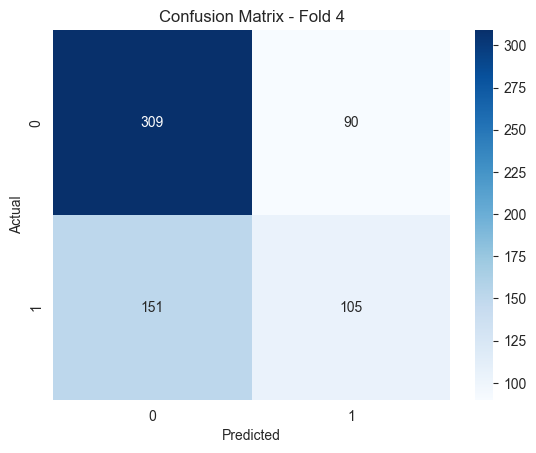

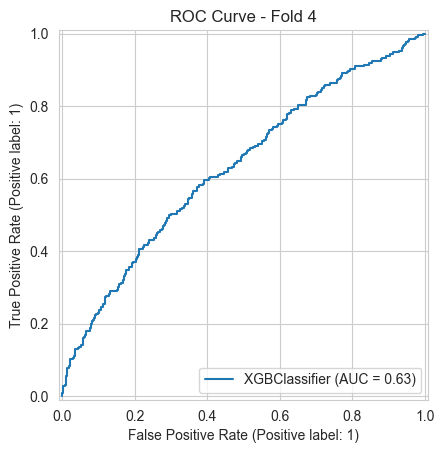

c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:51:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


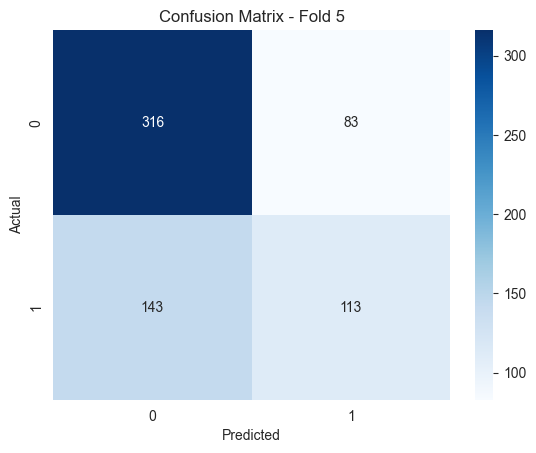

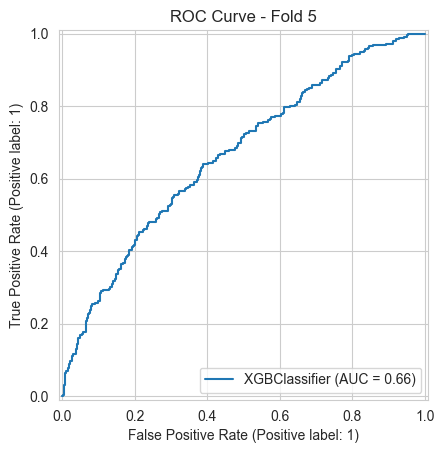

=== Cross Validation Results (5-Fold) ===
Average Accuracy: 0.650
Average Precision: 0.566
Average Recall: 0.441
Average F1 Score: 0.495
Average ROC AUC: 0.654


In [35]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load and prepare dataset
df = pd.read_csv(r"D:\FINAL WATER POTABILITY\water_potability.csv")
df_imputed = df.fillna(df.mean())

# Step 3: Features and target
X = df_imputed.drop("Potability", axis=1)
y = df_imputed["Potability"]

# Step 4: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Define model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Step 6: Stratified K-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 7: Initialize metrics storage
acc_scores, prec_scores, rec_scores, f1_scores, roc_scores = [], [], [], [], []

# Step 8: Cross-validation loop
fold = 1
for train_index, test_index in skf.split(X_scaled, y):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    xgb_model.fit(X_train, y_train)

    # Predictions
    y_pred = xgb_model.predict(X_test)
    y_prob = xgb_model.predict_proba(X_test)[:,1]

    # Compute metrics
    acc_scores.append(accuracy_score(y_test, y_pred))
    prec_scores.append(precision_score(y_test, y_pred))
    rec_scores.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    roc_scores.append(roc_auc_score(y_test, y_prob))

    # Confusion Matrix per fold
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC Curve per fold
    RocCurveDisplay.from_estimator(xgb_model, X_test, y_test)
    plt.title(f'ROC Curve - Fold {fold}')
    plt.show()

    fold += 1

# Step 9: Print average metrics
print("=== Cross Validation Results (5-Fold) ===")
print(f"Average Accuracy: {np.mean(acc_scores):.3f}")
print(f"Average Precision: {np.mean(prec_scores):.3f}")
print(f"Average Recall: {np.mean(rec_scores):.3f}")
print(f"Average F1 Score: {np.mean(f1_scores):.3f}")
print(f"Average ROC AUC: {np.mean(roc_scores):.3f}")


Calibration & thresholds
If false positives/negatives have different costs, adjust probability threshold (not always 0.5). Use calibration (Platt scaling / isotonic) if probabilities are off.

In [36]:
from sklearn.calibration import CalibratedClassifierCV
calibrated = CalibratedClassifierCV(rs.best_estimator_, cv=3)
calibrated.fit(X_train, y_train)


c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:53:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:53:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:53:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"XGBClassifier...ree=None, ...)"
,method,'sigmoid'
,cv,3
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


Ensembling / stacking
Stack best models (e.g., XGB + RF + Logistic) to squeeze extra performance.

In [37]:
from sklearn.ensemble import StackingClassifier
estimators = [
    ('rf', RandomForestClassifier(random_state=RANDOM_SEED)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_SEED))
]
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=5, n_jobs=-1)
stack.fit(X_train, y_train)


,estimators,"[('rf', ...), ('xgb', ...)]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


 Explainability (essential)
Use SHAP to explain model predictions and produce plots.



ExactExplainer explainer: 3277it [05:16, 10.34it/s]                          
C:\Users\krahu\AppData\Local\Temp\ipykernel_19292\858587270.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


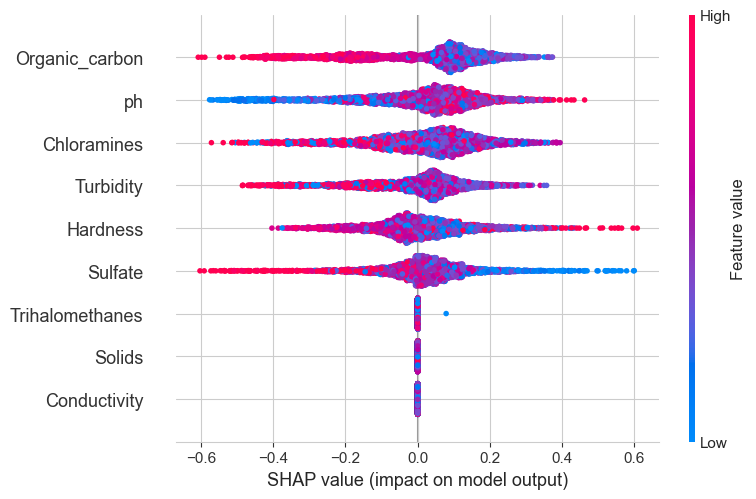

In [38]:
import shap
explainer = shap.Explainer(rs.best_estimator_.predict, X)  # or .predict_proba
shap_values = explainer(X)
shap.summary_plot(shap_values, X)


Final evaluation + reporting
Evaluate on hold-out test set (never used in training/tuning).

Produce confusion matrix, classification report, ROC AUC, PR curve.

Save figures & tables for report.

In [41]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
y_test_pred = xgb_model.predict(X_test)
print(classification_report(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.69      0.79      0.74       399
           1       0.58      0.44      0.50       256

    accuracy                           0.65       655
   macro avg       0.63      0.62      0.62       655
weighted avg       0.64      0.65      0.64       655

ROC AUC: 0.6646792763157894


Save model, scaler & artifacts


In [43]:
import joblib
joblib.dump(xgb_model, "water_quality_model_optimized.pkl")
joblib.dump(scaler, "scaler.pkl")
# Save feature order
joblib.dump(list(X.columns), "feature_order.pkl")


['feature_order.pkl']

 Final prediction cell 

In [47]:
import joblib, numpy as np

model = joblib.load("water_quality_model_optimized.pkl")
scaler = joblib.load("scaler.pkl")        # if you saved it
feature_order = joblib.load("feature_order.pkl")

# new sample (must follow feature_order)
new_sample = [[5.62, 230.85, 14442.42, 5.21, 0, 346.55, 11.36, 43.19, 1.94]]
# if you use transforms (log1p) do them exactly as training:
# new_sample_trans = [np.log1p(val) for val in new_sample[0]]  # example

new_scaled = scaler.transform(new_sample)
pred = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)[:,1]

print("Pred:", pred[0], "Prob potable:", prob[0])
if pred[0] == 1:
    print(" Water is Potable (Safe to Drink)")
else:
    print(" Water is Not Potable (Unsafe to Drink)")


Pred: 1 Prob potable: 0.87261057
 Water is Potable (Safe to Drink)


c:\Users\krahu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
